In [5]:
import pandas as pd

fake = pd.read_csv("../data/Fake.csv")
true = pd.read_csv("../data/True.csv")

In [6]:
# -----------------------------
# 2. Add labels
# -----------------------------
fake['label'] = 0   # Fake
true['label'] = 1   # Real

In [7]:

# -----------------------------
# 3. Combine datasets
# -----------------------------
df = pd.concat([fake, true])

In [8]:

# -----------------------------
# 4. Shuffle dataset
# -----------------------------
df = df.sample(frac=1).reset_index(drop=True)

In [9]:
# -----------------------------
# 5. Remove missing values
# -----------------------------
df = df.dropna()


In [1]:
import re 
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = re.sub('[^a-zA-Z]', ' ', text)
    text = text.lower()
    words = [w for w in text.split() if w not in stop_words]
    return ' '.join(words)

In [14]:
print(df.columns.tolist())

['title', 'text', 'subject', 'date', 'label']


In [11]:
df['content'] = df['title'] + " " + df['text']


In [40]:
print(df.duplicated(subset='content').sum())

0


In [12]:
df = df.drop_duplicates(subset='content')

In [13]:
df['content'] = df['content'].apply(preprocess)

In [44]:
print(df.columns)

Index(['title', 'text', 'subject', 'date', 'label', 'content'], dtype='object')


In [14]:

# -----------------------------
# 9. Final dataset
# -----------------------------
X = df['content']   # Features
y = df['label']     # Labels

In [46]:
# -----------------------------
# 10. Save cleaned data (optional)
# -----------------------------
df.to_csv("../data/cleaned_news.csv", index=False)

In [47]:
# -----------------------------
# Preview
# -----------------------------
print(df[['content', 'label']].head())

                                             content  label
0  senator grassley asks defense department expla...      1
1  watch obama mention times hillary endorsement ...      0
2  trump narrows high court search name conservat...      1
3  factbox key policies austria conservative far ...      1
4  obama union leaders sell american workers turn...      0


In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(X)

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True, random_state=42
)

In [17]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [18]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9904104334484082
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      3551
           1       0.99      1.00      0.99      4270

    accuracy                           0.99      7821
   macro avg       0.99      0.99      0.99      7821
weighted avg       0.99      0.99      0.99      7821



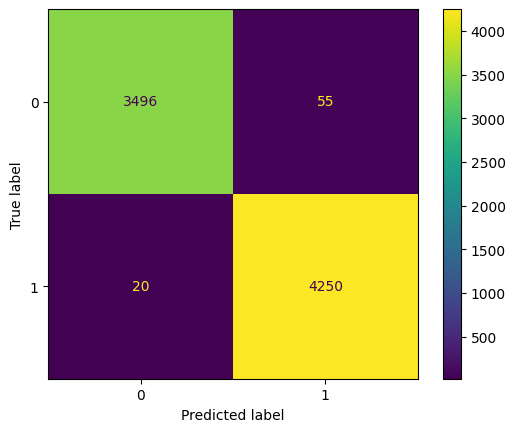

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

In [20]:
import subprocess
subprocess.check_call(['pip', 'install', 'matplotlib'])

0

In [62]:
samples = [
    "Aliens landed in India yesterday",
    "Stock market rises due to economic growth",
    "Drinking water cures all diseases instantly"
]

sample_vec = vectorizer.transform(samples)
print(model.predict(sample_vec))

[0 1 0]


In [ ]:
print(df.duplicated(subset='content').sum())

0


In [57]:
def predict_news(text):
    # same preprocessing function you used earlier
    text = preprocess(text)
    vector = vectorizer.transform([text])
    result = model.predict(vector)
    
    if result[0] == 1:
        return "REAL NEWS"
    else:
        return "FAKE NEWS"

# Test example
print(predict_news("Government announces new policy to reduce fuel prices starting next month"))

REAL NEWS


In [58]:
def predict_news(text):
    # same preprocessing function you used earlier
    text = preprocess(text)
    vector = vectorizer.transform([text])
    result = model.predict(vector)
    
    if result[0] == 1:
        return "REAL NEWS"
    else:
        return "FAKE NEWS"

# Test example
print(predict_news("Aliens have secretly taken control of the government officials"))

FAKE NEWS


In [63]:
import pickle

pickle.dump(model, open("../models/model.pkl", "wb"))
pickle.dump(vectorizer, open("../models/vectorizer.pkl", "wb"))